# Agente inteligente para predicción y evaluación por AUC

Este notebook implementa un agente inteligente en Python que coordina todo el proceso:

1. Carga del dataset.
2. Limpieza básica.
3. Detección de variables numéricas y categóricas.
4. División en entrenamiento y prueba.
5. Preprocesamiento automático.
6. Entrenamiento de varios modelos.
7. Evaluación mediante AUC.
8. Selección automática del mejor modelo.
9. Predicción final sobre nuevos datos.

> Cambie únicamente la ruta del archivo y el nombre de la variable objetivo.

In [21]:
# ===============================
# CELDA 1: Instalación opcional
# ===============================
# Si alguna librería no está instalada, quite el comentario y ejecute:
# !pip install pandas numpy scikit-learn matplotlib joblib

In [22]:
# ===============================
# CELDA 2: Importación de librerías
# ===============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

import matplotlib.pyplot as plt
import joblib

RANDOM_STATE = 42

In [23]:
# ===============================
# CELDA 3: Clase del agente inteligente
# ===============================

class IntelligentAUCAgent:
    def __init__(self, target_column, test_size=0.25, random_state=42):
        self.target_column = target_column
        self.test_size = test_size
        self.random_state = random_state

        self.data = None
        self.X = None
        self.y = None
        self.y_encoder = None

        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None

        self.numeric_features = None
        self.categorical_features = None
        self.preprocessor = None

        self.models = {}
        self.results = None
        self.best_model_name = None
        self.best_model = None

    def load_dataset(self, path):
        print("1. Cargando dataset...")
        self.data = pd.read_csv(path)
        print(f"Dataset cargado con {self.data.shape[0]} filas y {self.data.shape[1]} columnas.")
        return self.data.head()

    def inspect_dataset(self):
        print("2. Información general del dataset:")
        display(self.data.head())
        print("\nDimensiones:", self.data.shape)
        print("\nValores nulos por columna:")
        display(self.data.isnull().sum())
        print("\nTipos de datos:")
        display(self.data.dtypes)

    def prepare_features_target(self):
        print("3. Separando variables predictoras y variable objetivo...")

        if self.target_column not in self.data.columns:
            raise ValueError(f"La columna objetivo '{self.target_column}' no existe en el dataset.")

        df = self.data.copy()
        df = df.drop_duplicates()

        self.X = df.drop(columns=[self.target_column])
        self.y = df[self.target_column]

        # Codifica la variable objetivo si no es numérica
        if self.y.dtype == "object" or str(self.y.dtype).startswith("category"):
            self.y_encoder = LabelEncoder()
            self.y = self.y_encoder.fit_transform(self.y)
            print("Variable objetivo codificada automáticamente.")
            print("Clases:", list(self.y_encoder.classes_))

        unique_classes = np.unique(self.y)
        if len(unique_classes) != 2:
            raise ValueError(
                "Este agente está configurado para clasificación binaria y AUC binario. "
                f"Clases encontradas: {unique_classes}"
            )

        self.numeric_features = self.X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
        self.categorical_features = self.X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

        print("Variables numéricas:", self.numeric_features)
        print("Variables categóricas:", self.categorical_features)

    def split_data(self):
        print("4. Dividiendo datos en entrenamiento y prueba...")
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, 
            self.y,
            test_size=self.test_size,
            random_state=self.random_state,
            stratify=self.y
        )
        print("Entrenamiento:", self.X_train.shape)
        print("Prueba:", self.X_test.shape)

    def build_preprocessor(self):
        print("5. Construyendo preprocesamiento automático...")

        numeric_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        categorical_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])

        self.preprocessor = ColumnTransformer(
            transformers=[
                ("num", numeric_transformer, self.numeric_features),
                ("cat", categorical_transformer, self.categorical_features)
            ]
        )

        print("Preprocesamiento creado correctamente.")

    def define_models(self):
        print("6. Definiendo modelos candidatos...")

        self.models = {
            "Regresión Logística": LogisticRegression(max_iter=1000, random_state=self.random_state),
            "Árbol de Decisión": DecisionTreeClassifier(random_state=self.random_state),
            "Random Forest": RandomForestClassifier(n_estimators=200, random_state=self.random_state),
            "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=self.random_state),
            "Gradient Boosting": GradientBoostingClassifier(random_state=self.random_state),
            "KNN": KNeighborsClassifier(n_neighbors=5),
            "SVM RBF": SVC(kernel="rbf", probability=True, random_state=self.random_state),
            "Naive Bayes": GaussianNB()
        }

        print(f"{len(self.models)} modelos definidos.")

    def train_and_evaluate(self):
        print("7. Entrenando y evaluando modelos por AUC...")

        results = []

        for name, model in self.models.items():
            print(f"Entrenando: {name}")

            pipeline = Pipeline(steps=[
                ("preprocessor", self.preprocessor),
                ("model", model)
            ])

            try:
                pipeline.fit(self.X_train, self.y_train)

                y_pred = pipeline.predict(self.X_test)
                y_proba = pipeline.predict_proba(self.X_test)[:, 1]

                auc = roc_auc_score(self.y_test, y_proba)
                accuracy = accuracy_score(self.y_test, y_pred)

                results.append({
                    "Modelo": name,
                    "AUC": auc,
                    "Accuracy": accuracy,
                    "Pipeline": pipeline
                })

            except Exception as e:
                print(f"Error con el modelo {name}: {e}")

        self.results = pd.DataFrame(results).sort_values(by="AUC", ascending=False).reset_index(drop=True)

        self.best_model_name = self.results.loc[0, "Modelo"]
        self.best_model = self.results.loc[0, "Pipeline"]

        print("\nMejor modelo:", self.best_model_name)
        print("Mejor AUC:", round(self.results.loc[0, "AUC"], 4))

        return self.results[["Modelo", "AUC", "Accuracy"]]

    def show_auc_chart(self):
        print("8. Gráfico comparativo de AUC...")

        chart_data = self.results[["Modelo", "AUC"]].copy()
        chart_data = chart_data.sort_values("AUC", ascending=True)

        plt.figure(figsize=(10, 6))
        plt.barh(chart_data["Modelo"], chart_data["AUC"])
        plt.xlabel("AUC")
        plt.ylabel("Modelo")
        plt.title("Comparación de modelos según AUC")
        plt.xlim(0, 1)
        plt.show()

    def final_report(self):
        print("9. Reporte final del mejor modelo")

        y_pred = self.best_model.predict(self.X_test)
        y_proba = self.best_model.predict_proba(self.X_test)[:, 1]

        print("Modelo seleccionado:", self.best_model_name)
        print("AUC:", round(roc_auc_score(self.y_test, y_proba), 4))
        print("Accuracy:", round(accuracy_score(self.y_test, y_pred), 4))

        print("\nMatriz de confusión:")
        print(confusion_matrix(self.y_test, y_pred))

        print("\nReporte de clasificación:")
        print(classification_report(self.y_test, y_pred))

        RocCurveDisplay.from_predictions(self.y_test, y_proba)
        plt.title(f"Curva ROC - {self.best_model_name}")
        plt.show()

    def predict_new_data(self, new_data):
        print("10. Realizando predicción sobre nuevos datos...")

        if isinstance(new_data, dict):
            new_data = pd.DataFrame([new_data])

        pred_class = self.best_model.predict(new_data)
        pred_proba = self.best_model.predict_proba(new_data)[:, 1]

        result = pd.DataFrame({
            "Predicción_clase": pred_class,
            "Probabilidad_clase_positiva": pred_proba
        })

        if self.y_encoder is not None:
            result["Predicción_original"] = self.y_encoder.inverse_transform(pred_class)

        return result

    def save_best_model(self, filename="best_auc_model.pkl"):
        joblib.dump(self.best_model, filename)
        print(f"Modelo guardado como: {filename}")

    def run_all(self, path):
        self.load_dataset(path)
        self.inspect_dataset()
        self.prepare_features_target()
        self.split_data()
        self.build_preprocessor()
        self.define_models()
        display(self.train_and_evaluate())
        self.show_auc_chart()
        self.final_report()

In [24]:
# ===============================
# CELDA 4: Configuración del dataset
# ===============================
# Cambie esta ruta por la ruta real de su archivo CSV.
# Ejemplo en Mac:
# DATASET_PATH = "/Users/juan/Desktop/potabilidad_V2.csv"

DATASET_PATH = "/home/dnunezf/Documents/AI_LABS/Lab_21-05-2026/potabilidad_V2.csv"

# Cambie este nombre por la columna objetivo real.
# Ejemplo: "Potability", "target", "class", "diagnosis", etc.
TARGET_COLUMN = "Potability"

1. Cargando dataset...
Dataset cargado con 2011 filas y 11 columnas.
2. Información general del dataset:


,Unnamed: 0,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,4,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,No
1,5,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,No
2,6,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,54.917862,2.559708,No
3,7,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,84.603556,2.672989,No
4,8,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,62.798309,4.401425,No



Dimensiones: (2011, 11)

Valores nulos por columna:


Unnamed: 0         0
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


Tipos de datos:


Unnamed: 0           int64
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability          object
dtype: object

3. Separando variables predictoras y variable objetivo...
Variable objetivo codificada automáticamente.
Clases: ['No', 'Si']
Variables numéricas: ['Unnamed: 0', 'ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']
Variables categóricas: []
4. Dividiendo datos en entrenamiento y prueba...
Entrenamiento: (1508, 10)
Prueba: (503, 10)
5. Construyendo preprocesamiento automático...
Preprocesamiento creado correctamente.
6. Definiendo modelos candidatos...
8 modelos definidos.
7. Entrenando y evaluando modelos por AUC...
Entrenando: Regresión Logística
Entrenando: Árbol de Decisión
Entrenando: Random Forest
Entrenando: Extra Trees
Entrenando: Gradient Boosting
Entrenando: KNN
Entrenando: SVM RBF
Entrenando: Naive Bayes

Mejor modelo: Gradient Boosting
Mejor AUC: 0.9895


,Modelo,AUC,Accuracy
0,Gradient Boosting,0.989507,0.990060
1,Árbol de Decisión,0.987685,0.990060
2,Extra Trees,0.960616,0.878728
3,Random Forest,0.944376,0.858847
4,SVM RBF,0.764278,0.693837
5,KNN,0.692479,0.664016
6,Naive Bayes,0.619360,0.606362
7,Regresión Logística,0.495911,0.546720


8. Gráfico comparativo de AUC...


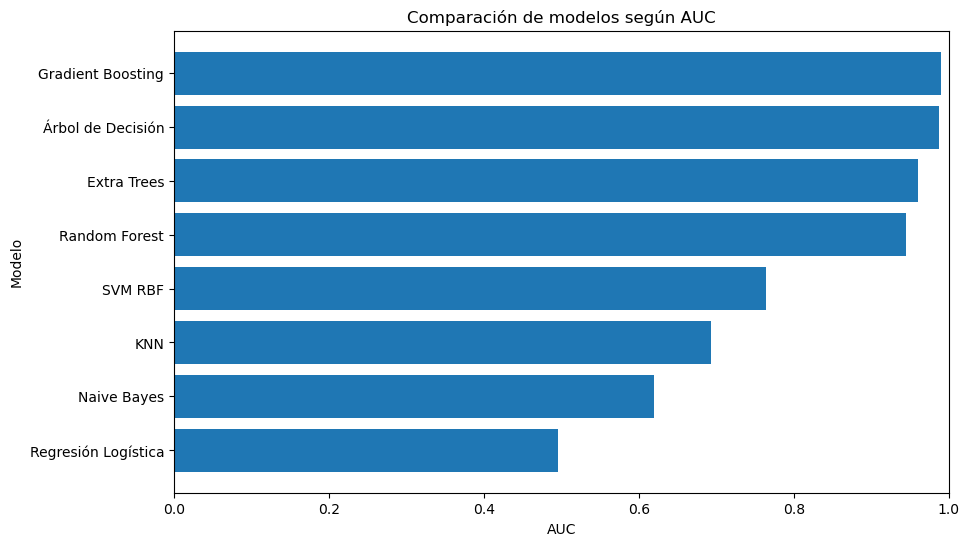

9. Reporte final del mejor modelo
Modelo seleccionado: Gradient Boosting
AUC: 0.9895
Accuracy: 0.9901

Matriz de confusión:
[[300   0]
 [  5 198]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       300
           1       1.00      0.98      0.99       203

    accuracy                           0.99       503
   macro avg       0.99      0.99      0.99       503
weighted avg       0.99      0.99      0.99       503



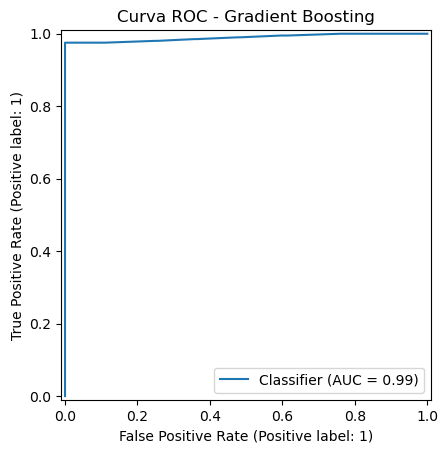

In [25]:
# ===============================
# CELDA 5: Crear y ejecutar el agente completo
# ===============================

agent = IntelligentAUCAgent(
    target_column=TARGET_COLUMN,
    test_size=0.25,
    random_state=42
)

agent.run_all(DATASET_PATH)

In [26]:
# ===============================
# CELDA 6: Ver tabla final de resultados
# ===============================

agent.results[["Modelo", "AUC", "Accuracy"]]

,Modelo,AUC,Accuracy
0,Gradient Boosting,0.989507,0.990060
1,Árbol de Decisión,0.987685,0.990060
2,Extra Trees,0.960616,0.878728
3,Random Forest,0.944376,0.858847
4,SVM RBF,0.764278,0.693837
5,KNN,0.692479,0.664016
6,Naive Bayes,0.619360,0.606362
7,Regresión Logística,0.495911,0.546720


In [27]:
# ===============================
# CELDA 7: Predicción con un nuevo registro
# ===============================
# Importante:
# El nuevo registro debe tener las mismas columnas predictoras del dataset original,
# excepto la variable objetivo.

nuevo_registro = agent.X_test.iloc[0].to_dict()

prediccion = agent.predict_new_data(nuevo_registro)
prediccion

10. Realizando predicción sobre nuevos datos...


,Predicción_clase,Probabilidad_clase_positiva,Predicción_original
0,0,0.075676,No


In [28]:
# ===============================
# CELDA 8: Guardar el mejor modelo
# ===============================

agent.save_best_model("mejor_modelo_auc.pkl")

Modelo guardado como: mejor_modelo_auc.pkl


In [29]:
# ===============================
# CELDA 9: Cargar el modelo guardado
# ===============================

modelo_cargado = joblib.load("mejor_modelo_auc.pkl")

# Ejemplo de predicción con el modelo cargado
modelo_cargado.predict(agent.X_test.iloc[[0]])

array([0])

## Interpretación básica del AUC

- AUC cercano a 0.50: el modelo casi no discrimina entre clases.
- AUC entre 0.60 y 0.70: desempeño bajo o moderado.
- AUC entre 0.70 y 0.80: desempeño aceptable.
- AUC entre 0.80 y 0.90: buen desempeño.
- AUC mayor a 0.90: desempeño muy alto.

El mejor modelo será el que obtenga el AUC más alto en el conjunto de prueba.